# MULTIPLE LINEAR REGRESSION

### Assignment Task:

In [1]:
## Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.

### Dataset Description:

In [2]:
## The dataset consists of the following variables:
## Age: Age in years
## KM: Accumulated Kilometers on odometer
## FuelType: Fuel Type (Petrol, Diesel, CNG)
## HP: Horse Power
## Automatic: Automatic ( (Yes=1, No=0)
## CC: Cylinder Volume in cubic centimeters
## Doors: Number of doors
## Weight: Weight in Kilograms
## Quarterly_Tax: 
## Price: Offer Price in EUROs

### Tasks:

In [3]:
## 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables.Preprocess the data to apply the MLR.
## 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).
## 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build minimum of 3 different models.
## 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.
## 5.Apply Lasso and Ridge methods on the model.

### Interview Questions:
## 1.What is Normalization &Standardization and how is it helpful?
## 2.What techniques can be used to address multicollinearity in multiple linear regression?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## loaded basic required libraries which will be used through out this multilinear regression model building process..

In [5]:
df = pd.read_csv("ToyotaCorolla_MLR.csv")
df.head()

## dataset is loaded into pandas dataframe to variable df..
## used head() function to see 1st 5 records of the dataset.. 

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [6]:
df.info()
## used info() fuction to examine the datatype of each column of dataset..
## it also helps us to find out the presence of any null values in the dataset.. 
## Fuel_Type is in object datatype.. we might have to convert it into numerical column before building the model.. (encoding)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
df.describe()
## describe() fuction shows us the whole statistical summary at once of all the numerical column in the dataset..
## it shows us the mean, standared deviation, min and max values in a column and also the values for 25, 50 and 75 percentile values for each column..
## 50 percentile value is nothing but median value..

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [8]:
df.isnull().sum()
## isnull().sum() is used to check the number of null values in each of the columns of the dataset..

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [9]:
## This dataset contains 1436 records and 11 columns including 10 input columns and 1 targert variable(Price)..
## The input variable describe characteristics of toyota corolla cars such as age, kilometer driven, fuel type, horsepower, weight and transmission type.. 
## No missing values were found in the dataset. It means dataset is complete and ready for EDA process.. 

In [10]:
## lets take all the numerical column names into one variable..
num_cols = df.select_dtypes(include = ["int64", "float64"]).columns
print(num_cols)

Index(['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight'],
      dtype='object')


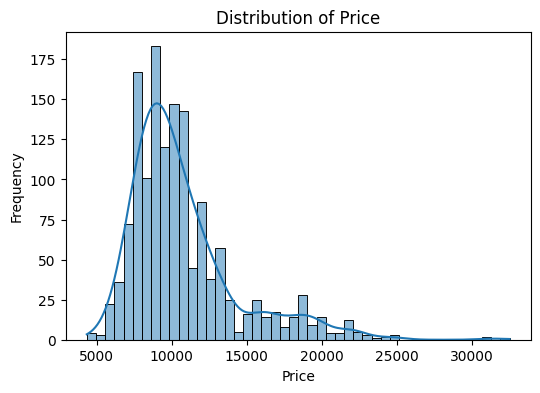

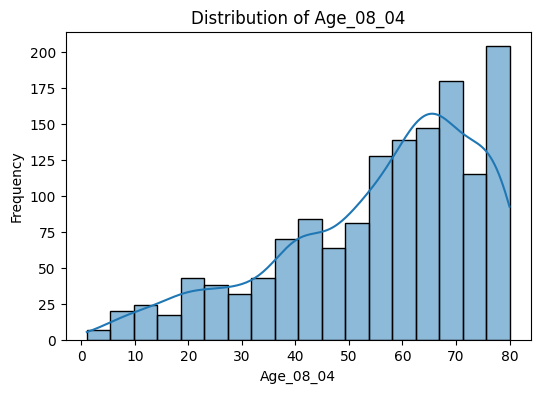

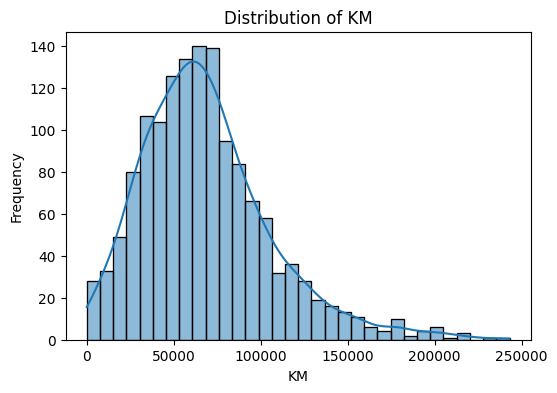

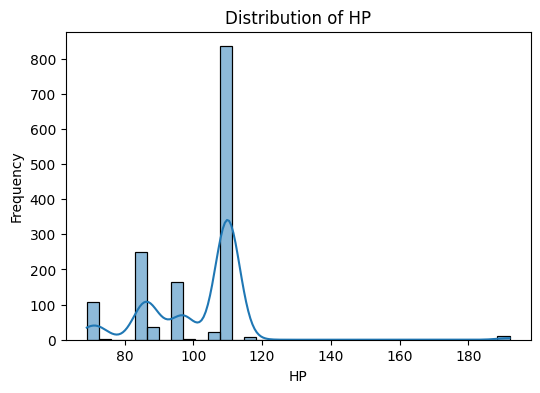

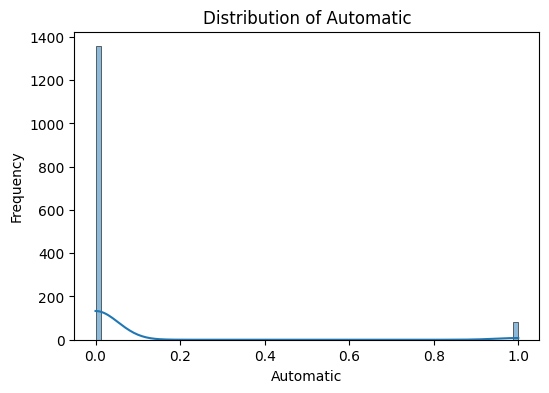

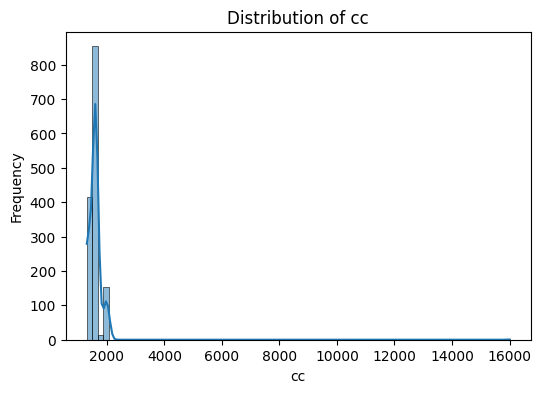

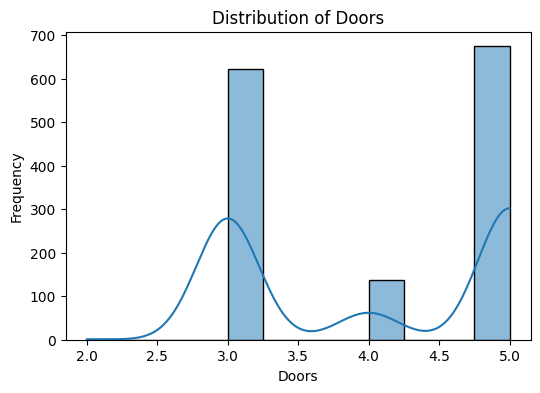

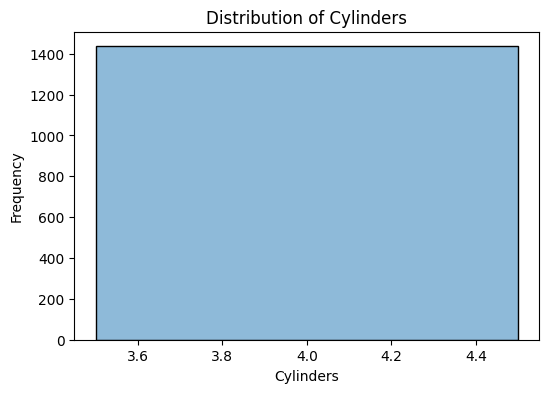

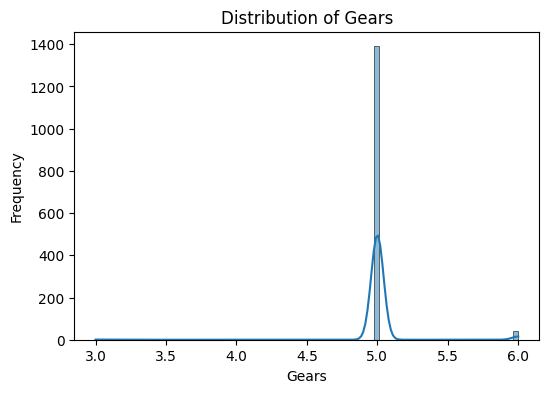

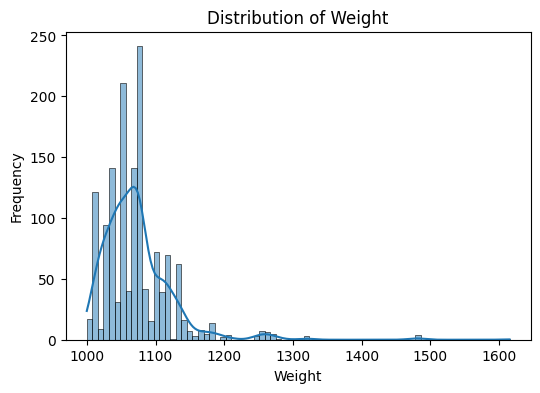

In [11]:
## now lets write a 'for' loop for histogram plot for each of these numerical columns to underrstand their distribution..
for i in num_cols:
    plt.figure(figsize = (6, 4))
    sns.histplot(df[i], kde = True)
    plt.title(f"Distribution of {i}")
    plt.xlabel(i)
    plt.ylabel("Frequency")
    plt.show()

In [12]:
## above step will help us identify skewness, spread of the  data and whether any variable contain extreme values or unsual patterns..

## The histograms shows the distribution of the numerical variables in the dataset.. 
## The price of the car varies widely with most cars priced between 8450 and 11950 Euros..
## The age of the car ranges from very new to around 80 years old..
## The 'KM' variable shows slight high variations.. some cars have been driven much more than others..
## Most cars have horse power between 90 and 110..
## The majority of the vehicle are of manual transmission and most of the cars have either 3 or 5 doors..
## Almost all the cars have 5 gears and 4 cylinders..
## The weight of the cars is fairly consistent acrosds the dadtaset with only small variations..


Column: Price
Q1 : 8450.0
Q3 : 11950.0
IQR : 3500.0
Lower Bound : 3200.0
Upper Bound : 17200.0
Minimum Value : 4350
Maximum Value : 32500
Potential Outiers : 110


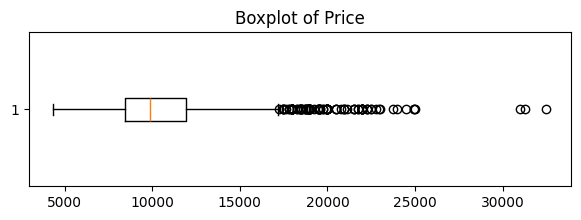

****************************************************************************************************

Column: Age_08_04
Q1 : 44.0
Q3 : 70.0
IQR : 26.0
Lower Bound : 5.0
Upper Bound : 109.0
Minimum Value : 1
Maximum Value : 80
Potential Outiers : 7


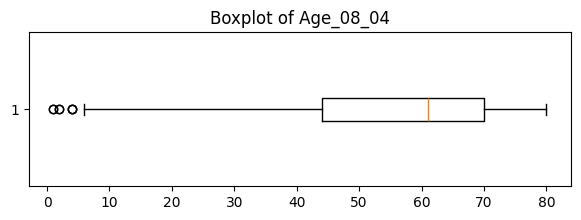

****************************************************************************************************

Column: KM
Q1 : 43000.0
Q3 : 87020.75
IQR : 44020.75
Lower Bound : -23031.125
Upper Bound : 153051.875
Minimum Value : 1
Maximum Value : 243000
Potential Outiers : 49


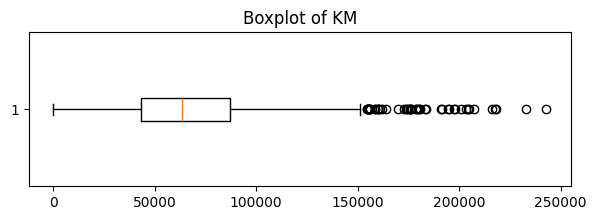

****************************************************************************************************

Column: HP
Q1 : 90.0
Q3 : 110.0
IQR : 20.0
Lower Bound : 60.0
Upper Bound : 140.0
Minimum Value : 69
Maximum Value : 192
Potential Outiers : 11


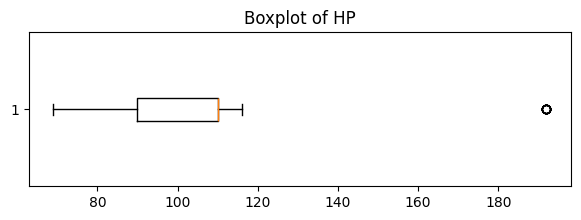

****************************************************************************************************

Column: Automatic
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Lower Bound : 0.0
Upper Bound : 0.0
Minimum Value : 0
Maximum Value : 1
Potential Outiers : 80


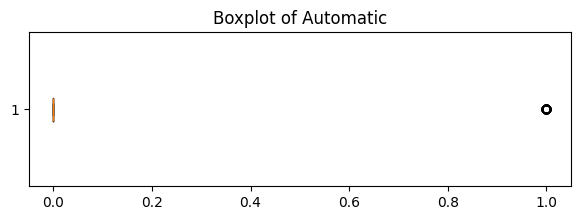

****************************************************************************************************

Column: cc
Q1 : 1400.0
Q3 : 1600.0
IQR : 200.0
Lower Bound : 1100.0
Upper Bound : 1900.0
Minimum Value : 1300
Maximum Value : 16000
Potential Outiers : 123


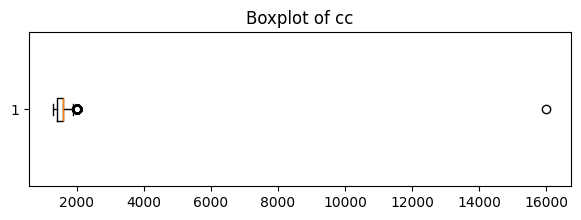

****************************************************************************************************

Column: Doors
Q1 : 3.0
Q3 : 5.0
IQR : 2.0
Lower Bound : 0.0
Upper Bound : 8.0
Minimum Value : 2
Maximum Value : 5
Potential Outiers : 0


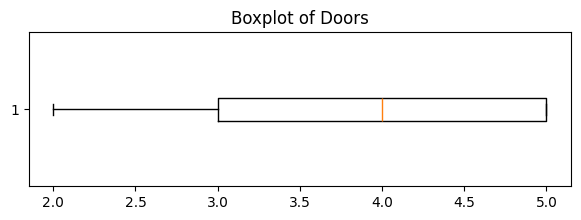

****************************************************************************************************

Column: Cylinders
Q1 : 4.0
Q3 : 4.0
IQR : 0.0
Lower Bound : 4.0
Upper Bound : 4.0
Minimum Value : 4
Maximum Value : 4
Potential Outiers : 0


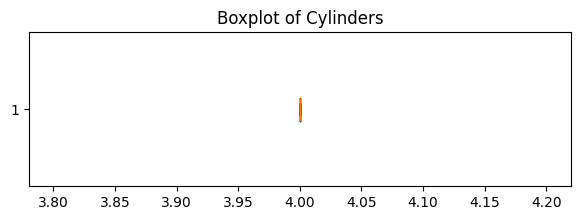

****************************************************************************************************

Column: Gears
Q1 : 5.0
Q3 : 5.0
IQR : 0.0
Lower Bound : 5.0
Upper Bound : 5.0
Minimum Value : 3
Maximum Value : 6
Potential Outiers : 46


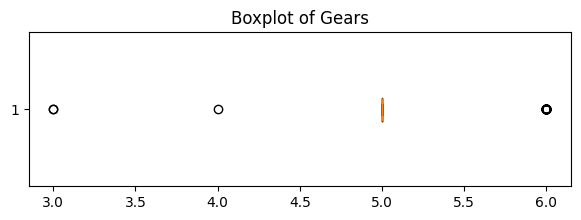

****************************************************************************************************

Column: Weight
Q1 : 1040.0
Q3 : 1085.0
IQR : 45.0
Lower Bound : 972.5
Upper Bound : 1152.5
Minimum Value : 1000
Maximum Value : 1615
Potential Outiers : 66


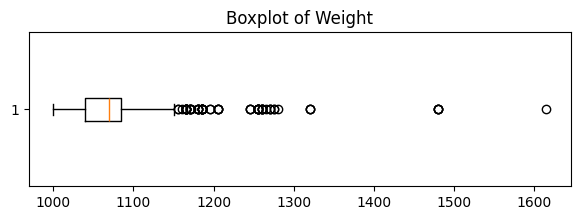

****************************************************************************************************


In [13]:
## now will plot boxplot to see outliers..

for i in num_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    min_val = df[i].min()
    max_val = df[i].max()

    ## detect outliers..
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)][i]

    print(f"\nColumn: {i}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Minimum Value : {min_val}")
    print(f"Maximum Value : {max_val}")
    print(f"Potential Outiers : {len(outliers)}")
#    if len(outliers) > 0:
#        print("Potential Outliers:")
#        print(outliers.values)
    
    plt.figure(figsize = (7, 2))
    plt.boxplot(df[i].dropna(), vert = False)
    plt.title(f"Boxplot of {i}")
    plt.show()

    print("*"*100)

In [14]:
## The boxplot shows the presence of outliers in several variables..
## The Price variable has many outliers on the higher side indicating a few cars with very high prices..
## The Age variable shows a few lower end outliers with more cars having relatively higher ages..
## The KM variable also shows several high outliers suggesting that some cars have been driven much more than the average..
## In the HP variable most cars fall between 90 and 110 HP with a small number of high power cars (192 HP)..
## The cc variable mostly ranges between 1400 and 1600 cc, although an unusally large maximum value is observed (a 16000 cc car)..
## Most cars are manual transmission, have 3 or 5 doors, 4 cylinders and 5 gears..
## The weight variable is fairly consistent but shows some higher side outliers..
## overall, while some extreme value exists, they may represent real variations in the car specifications..
## We wont't be removing these potential outiers blindly for now because dataset size is not too big, we do not want to loose any information ..
## we will check the model performance first.. it it performs bad then only we will look for aggressive removal of potential outliers

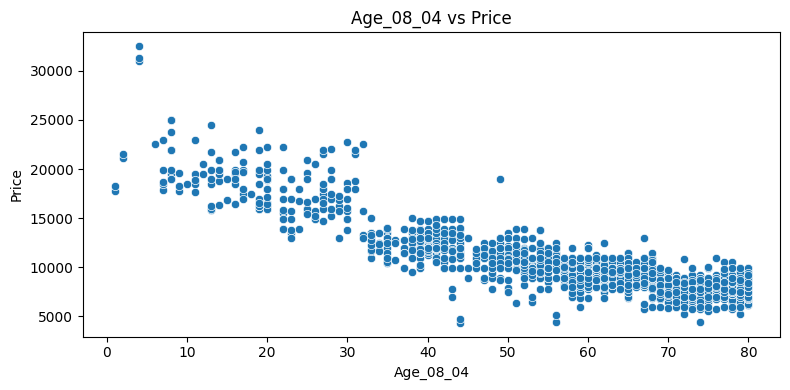

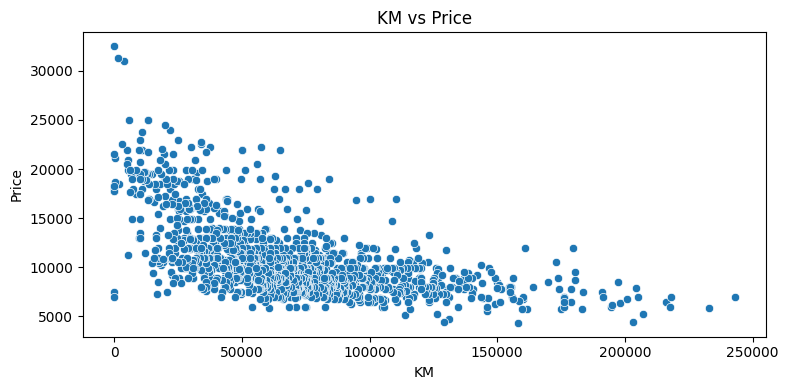

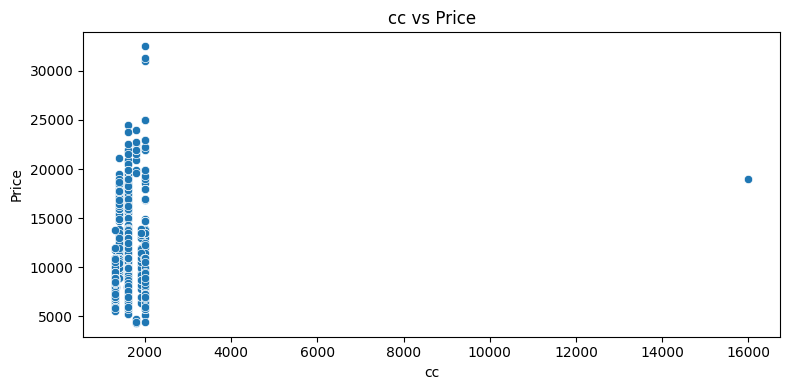

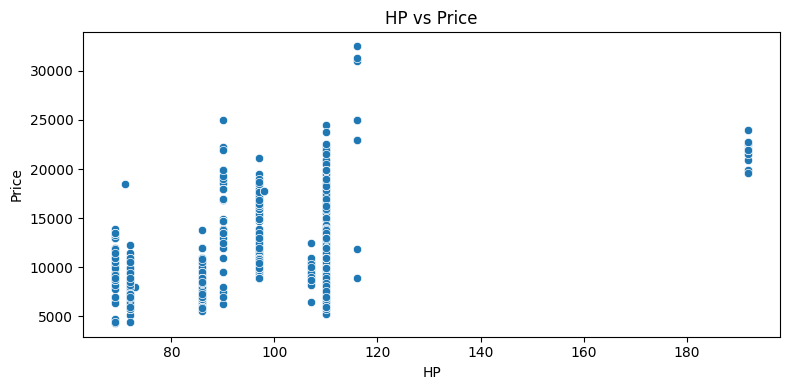

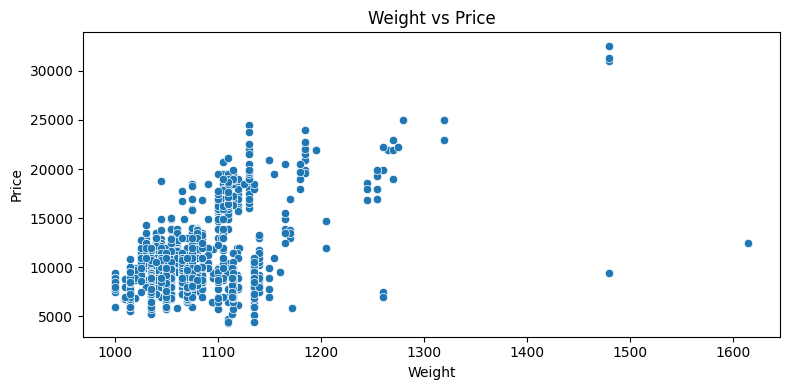

In [15]:
## study the relationship between independent variables and the dependent variable (targe variable).. 
## here we will exclude categorical variables or discrete variable (although they are in integer form) like Automatic,  Doors, Cylinders, Gears, Fuel_type..
## because scatter plots works best for continious variables only..

for i in ['Age_08_04', 'KM', 'cc', 'HP', 'Weight']:
    plt.figure(figsize =(8, 4))
    sns.scatterplot(x = df[i], y = df["Price"])
    plt.title(f"{i} vs Price")
    plt.xlabel(i)
    plt.tight_layout()
    plt.ylabel("Price")
    plt.show()

In [16]:
## For Age_08_04 vs Price :- The scattter plot shows that car price generally decreases as age increases..
## Older car tends to have lower prices.. however age alone does not fully determine the price, other factors may also influenec it.. 

## KM VS Price :- The icreasing trend can also be obeserved betweeen KM and Price.. 
## cars with more driven KMs tends to have lower prices.. however relationship appears slightly weaker compared to Age vs Price..
## It suggests that even though price seems dependent on KM, but KM is not the only factor suggesting this trend..

## cc vs Price :- The scatter plot does not show a clear relationship between them.. 
## Most cars are clustered around 2000 cc segment while one extreme value can be seen arount 16000 cc..
## some cars with similar cc values have different prices indicating that CC alone does not strongly influencing the Price..

## HP vs Price :- The relationship between HP and Price is weak..
## although a slight increasing pattern can be seen but many cars with lower HP are priced higher than some cars with higher HP..
## this suggests that HP alone is not a strong predictor by itself..

## Weight vs Price:- The scatter plot between them does not show a clear pattern
## while a few hevier cars appears to have higher prices but the overall relationship is not strong.. 

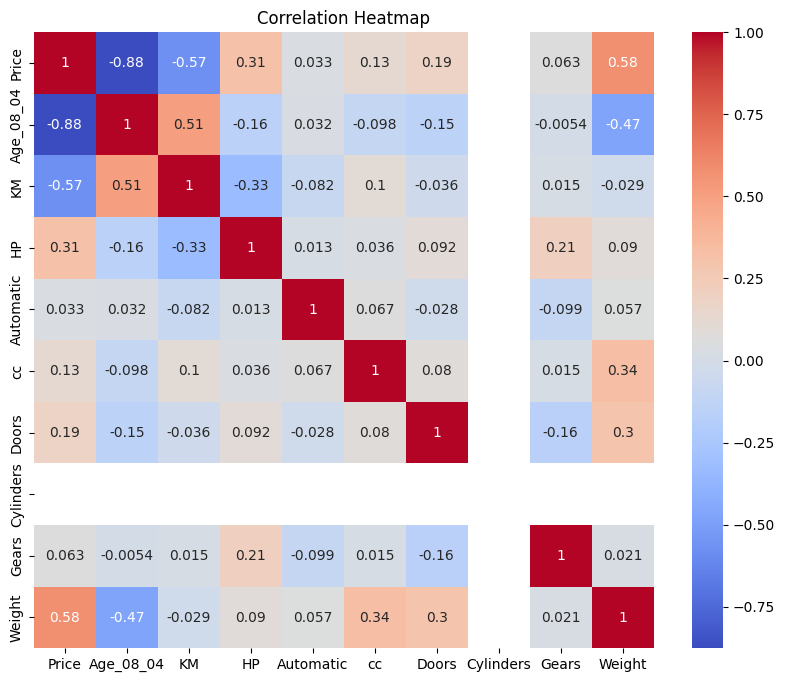

In [17]:
## heat map..
## to understand the relationship between numerical variables in the dataset with target variable
## also helps detecting multicollinearity..

plt.figure(figsize = (10, 8))
sns.heatmap(df[num_cols].corr(), annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
## The correlation heatmap shows the relationship between numerical variables in the dataset..
## Age_08_04 has a strong negative correlation with the Price (-0.88), indicating that older cars tends to have lower prices..
## KM also shows moderate negative correlation with the Price (-0.57), suggesting that cars driven more kilometers usually have lower prices..
## Weight has moderate positive correlation with the Price (0.58), meaning heavier cars tends to have higher prices..
## Hp shows a weak positive correlation with the Price (0.31), indicating a slight relationship..
## Most other variables show weak correlation with the price.. overall Age, KM, and Weight appears to be the most influential variables affecting car price..
## cylinder column is blank (white).. this probably happened because all the cars are having 4 cylinder only.. so this variable have 0 variance, hence correlation cannot be calculated..

In [19]:
## from the heatmap we saw that cylinder column has no variation.. 
## such vaiable do not help in model building so we remove them..
df = df.drop("Cylinders", axis = 1)
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Gears', 'Weight'],
      dtype='object')

In [20]:
## now lets encode Fuel_Type to convert that into numerical form and make it regression model ready input form..
## we will use one hot encoding for this.. 
df = pd.get_dummies(df, columns = ['Fuel_Type'], drop_first = True)

In [21]:
df.head()
## df = df.astype(int) if you want to see encoded columns in the form of 1 and 0 instead of True and False..
## its not necessary as True and False also works fine with regression models..

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,5,1165,True,False
1,13750,23,72937,90,0,2000,3,5,1165,True,False
2,13950,24,41711,90,0,2000,3,5,1165,True,False
3,14950,26,48000,90,0,2000,3,5,1165,True,False
4,13750,30,38500,90,0,2000,3,5,1170,True,False


In [22]:
df = df.astype(int)
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,5,1165,1,0
1,13750,23,72937,90,0,2000,3,5,1165,1,0
2,13950,24,41711,90,0,2000,3,5,1165,1,0
3,14950,26,48000,90,0,2000,3,5,1165,1,0
4,13750,30,38500,90,0,2000,3,5,1170,1,0


In [23]:
## Define X and Y before training the model.. x = input values, y = output values (target variables)
## Dataset is divided into independent variables (X) and dependent variable (Y).. 
X = df.drop("Price", axis = 1)
Y = df["Price"]

In [24]:
## Train Test Split (80/20)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y , test_size = 0.2, random_state = 42)

In [25]:
## The dataset was split into training and testing sets, with 80% used for training the model and 20% used for testing its performance

In [26]:
## Variance inflation factor :- it detects multicollinearity in between predictors.. 
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['Feature'] = x_train.columns
vif_data['VIF'] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]

print(vif_data)

            Feature         VIF
0         Age_08_04   16.745578
1                KM    8.821195
2                HP   98.739715
3         Automatic    1.168493
4                cc   14.914255
5             Doors   23.061981
6             Gears  531.209710
7            Weight  685.276459
8  Fuel_Type_Diesel   11.351805
9  Fuel_Type_Petrol   61.268214


In [27]:
## VIF analysis shows high multicollinearity among several predictors such as weight, Gears, HP, and cc.
## To improve more stability, highly correlated variables will be gradually removed as we proceed to secondary and third model..

#### Model 1

In [28]:
## Model 1:- Base model.. we will be using all the predictors for building this model..
from sklearn.linear_model import LinearRegression
model_1 = LinearRegression()
model_1.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
## prediction of test data..
y_pred_1 = model_1.predict(x_test)

In [30]:
## model coefficients.. 
coefficients = pd.DataFrame({"Features": x_train.columns, "Coefficients": model_1.coef_})
print(coefficients)

           Features  Coefficients
0         Age_08_04   -120.830458
1                KM     -0.016231
2                HP     14.039479
3         Automatic    148.830927
4                cc     -0.030372
5             Doors    -60.310974
6             Gears    551.600710
7            Weight     25.884958
8  Fuel_Type_Diesel    -68.548757
9  Fuel_Type_Petrol   1370.808910


In [31]:
## model evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2 Score: ", r2_score(y_test, y_pred_1))
print("MAE: ", mean_absolute_error(y_test, y_pred_1))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_1)))

R2 Score:  0.8348888040611084
MAE:  990.8872739193927
RMSE:  1484.2654153296508


In [32]:
## The coefficient of the regression model shows how each variable affects the car price while keeping other variables constant..
## The coefficient of Age_08_04 (-120.83) indicates that as the age of the car increases by 1 unit, the price decreases by about 120 eros..
## KM also has a negative coefficient (-0.016), suggesting that more driven cars tend to have slightly lower prices..
## HP and Weight have have positive coefficient meaning that cars with higher horsepower or greater weight tend to have higher prices..
## The Automatic column has a positive coefficient indicating that atomatic cars may have slightly higher prices compared to manual ones..
## Some variables like Doors and cc show small negative effects, indicating a weak relationship with price..
## Overall Age appears to be one of the strongest factors affecting the price..


## About the Model evaluation.. 
## The model achieved an R2 score of 0.83, means it explains 83% of the variation in car prices, which is decent..
## MAE means on average the prediction error is about 990 eros..
## RMSE = 1484.. larger error are slightly higher..

## Model 2

In [33]:
## For model 2 we will reduce multicollinearity by removing variable with extreamly high VIF values(Weight, Gears, HP)..
## Large VIF values means they are strongly correlated with other predictor..
## After removing them a new regression model will be built..

In [34]:
## lets create new feature set..
X2 = X.drop(['Weight', 'Gears', 'HP'], axis = 1)

In [35]:
## new train test split for model 2..
x2_train, x2_test, y_train, y_test = train_test_split(X2, Y , test_size = 0.2, random_state = 42)

In [36]:
## model 2 building process..
model_2 = LinearRegression()
model_2.fit(x2_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
## model 2 prediction..
y_pred_2 = model_2.predict(x2_test)

In [38]:
## model 2 evaluationn..
print("R2 Score: ", r2_score(y_test, y_pred_2))
print("MAE: ", mean_absolute_error(y_test, y_pred_2))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_2)))

R2 Score:  0.7924883566965575
MAE:  1124.999594559641
RMSE:  1663.9663575948264


In [39]:
## coefficient model 2..
coefficients_2 = pd.DataFrame({"Features": x2_train.columns, "Coefficients": model_2.coef_})
print(coefficients_2)

           Features  Coefficients
0         Age_08_04   -146.532533
1                KM     -0.019504
2         Automatic    710.651146
3                cc      0.371603
4             Doors    227.712340
5  Fuel_Type_Diesel    838.473119
6  Fuel_Type_Petrol    264.510507


In [40]:
## The model achieved a R2 score of 0.79, meaning it explains about 79% of variation in car prices..
## MAE:  1124.999594559641, RMSE:  1663.9663575948264
## Compared to model 1, the performance decreased slightly but the model is more stable because multicollinearity has been reduced..

In [41]:
## The coefficients indicates the relationship between predictor and price..
## Age_08_04 and KM have negative coefficients, showing older cars and cars with more driven kilometers tend to have lesser price..
## Automatic cars have positive coefficient, indicating they may have higher prices..
## CC, Doors and Fuel type variables show positive coefficients, suggesting that these features may increase the price of the car..

## Model 3

In [42]:
## create feature set for model 3..
X3 = X2.drop(['cc', 'Doors'], axis = 1) 
X3.columns

Index(['Age_08_04', 'KM', 'Automatic', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol'], dtype='object')

In [43]:
X2.head(2)

,Age_08_04,KM,Automatic,cc,Doors,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23,46986,0,2000,3,1,0
1,23,72937,0,2000,3,1,0


In [44]:
## train test split for model 3
x3_train, x3_test, y_train, y_test = train_test_split(X3, Y , test_size = 0.2, random_state = 42)

In [45]:
## build model 3
model_3 = LinearRegression()
model_3.fit(x3_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
# model 3 prediction..
y_pred_3 = model_3.predict(x3_test)

In [47]:
## model 3 evaluation..
print("R2 Score: ", r2_score(y_test, y_pred_3))
print("MAE: ", mean_absolute_error(y_test, y_pred_3))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_3)))

R2 Score:  0.7846497835434719
MAE:  1146.6485702484617
RMSE:  1695.1024941356568


In [48]:
## model coefficient
coefficients_3 = pd.DataFrame({"Features": x3_train.columns, "Coefficients": model_3.coef_})
print(coefficients_3)

           Features  Coefficients
0         Age_08_04   -149.273220
1                KM     -0.019039
2         Automatic    785.250194
3  Fuel_Type_Diesel    962.117182
4  Fuel_Type_Petrol    244.145162


In [49]:
## The model achieved a R2 score of 0.78, meaning it explains about 78% of variation in car prices..
## MAE:  1147 euros, RMSE:  1695 eros.. indicates the prediction error of the model..
## Although compared to model 1 and model 2, the performance decreased slightly but the model is simpler and easier to interpret.. 

In [50]:
## Regarding coefficients, Age_08_04 and KM  have negative coefficient.. older cars with more driven kilometers tends to have lower price..
## Automatic cars have positive coefficient, indicating they may have higher prices..
## Fuel type variables also showing positive values suggesting that certain fuel (Diesel) type may influence the price of the car more.. 

In [51]:
## Among the three models, Model 1 provided the best predictive performance, while Model 3 offered a simpler and more interpretable model..

#### Apply Lasso and Ridge methods on the model.

#### Ridge Regression

In [52]:
## importing the required library for ridge model
from sklearn.linear_model import Ridge

In [53]:
## model building..
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [54]:
## model prediction..
y_pred_ridge = ridge_model.predict(x_test)

In [55]:
## model evaluation..
print("R2 Score: ", r2_score(y_test, y_pred_ridge))
print("MAE: ", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

R2 Score:  0.8351359377712338
MAE:  990.7338342026012
RMSE:  1483.1541963778873


#### Lasso Regression

In [56]:
## importing the required library for lasso model
from sklearn.linear_model import Lasso

In [57]:
## model building..
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [58]:
## model prediction..
y_pred_lasso = lasso_model.predict(x_test)

In [59]:
## model evaluation..
print("R2 Score: ", r2_score(y_test, y_pred_lasso))
print("MAE: ", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

R2 Score:  0.8354626403967389
MAE:  990.9546616159035
RMSE:  1481.6839224634043


In [60]:
## These regularization is basically done to reduce overfitting and handle multicollinerity by adding a penalty to the regression model..
## Ridge regression was applied to reduce multicollinearity by adding an L2 regularization penalty to the regression model..
## Lasso regression was applied to perform regularization and feature selection by shriking less important coefficient toward zero..


## Ridge regression --> R2 Score:  0.8351359377712338, MAE:  990.7338342026012, RMSE:  1483.1541963778873
## Lasso regression --> R2 Score:  0.8354626403967389, MAE:  990.9546616159031, RMSE:  1481.6839224634043

In [61]:
## Among the three multiple linear regression models, Model 1 performed the best wityh the highest R2 score and lowest error values..
## Ridge and Lasso regression produced result very similar to Model 1, indicating that the model is alreday very stable and does not suffer heavily from overfitting..
## Therefore, Model 1 can be considered the most suitable model for predicting the price of Toyota corolla cars..

### Interview Questions:

#### 1.What is Normalization &Standardization and how is it helpful?

In [62]:
## Normalization and standardization is a process which is done to bring all the variables to the same scale..
## Normalization scales the data to a range between 0 and 1..
## Standardization transforms the data in terms of Z score so that it has mean = 0 and standard deviation = 1..
## Most of the values lies between -3 and +3 after standardzation, anything beyond these values are most probably outliers..
## They helps improve model performance, specially models that depends on distance based calculations such as KNN, SVM etc..

#### 2.What techniques can be used to address multicollinearity in multiple linear regression?

In [63]:
## Multicollinearity occurs when independent variables are highly correlated with each other..
## we can avoid this condition by removing highly correlated variables..
## By using VIF (Variance inflation factor) we can detect multicollinearity..
## It can also be controlled by applying regularization techniques like ridge and lasso regression..
## Using dimensionaity reduction methods like PCA.. 